In [8]:
# ============================================================
# Cell 1: Merge all metrics into a single dataframe
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "/Users/harshadghodke/AIML/pdl1-mini-binder-design/data/results"
BASE_DIR_rfd = "/Users/harshadghodke/Library/CloudStorage/GoogleDrive-hghodkephd@gmail.com/My Drive/Colab Notebooks/rfdiffusion_outputs"

BACKBONE_CSV = f"{BASE_DIR_rfd}/filtered_designs.csv"
SEQUENCE_CSV = f"{BASE_DIR}/proteinmpnn/all_mpnn_sequences.csv"
VALIDATION_CSV = f"{BASE_DIR}/esmfold_predictions/validation_results.csv"

df_backbones = pd.read_csv(BACKBONE_CSV)
df_sequences = pd.read_csv(SEQUENCE_CSV)
df_validation = pd.read_csv(VALIDATION_CSV)

print("Backbone columns:", df_backbones.columns.tolist())
print("Sequence columns:", df_sequences.columns.tolist())
print("Validation columns:", df_validation.columns.tolist())

# Start with validation results
df_all = df_validation.copy()

# Add binder sequence if missing
if "binder_sequence" not in df_all.columns:
    df_seq_lookup = (
        df_sequences
        .sort_values("mpnn_score")
        .drop_duplicates("backbone")
        [["backbone", "binder_sequence"]]
    )

    df_all = df_all.merge(
        df_seq_lookup,
        on="backbone",
        how="left"
    )

# Add RFdiffusion geometry metrics
df_all = df_all.merge(
    df_backbones,
    left_on="backbone",
    right_on="file",
    how="left",
    suffixes=("", "_rfdiffusion")
)

print(f"Total candidates with full metrics: {len(df_all)}")

display(df_all.head())

print("\nSummary statistics:")
display(df_all.describe())

Backbone columns: ['file', 'binder_chain', 'target_chain', 'n_residues', 'radius_of_gyration', 'atom_contacts', 'binder_contact_residues', 'target_contact_residues']
Sequence columns: ['backbone', 'header', 'full_sequence', 'target_sequence', 'binder_sequence', 'full_length', 'binder_length', 'mpnn_score', 'global_score', 'sequence_recovery']
Validation columns: ['seq_id', 'backbone', 'mean_plddt', 'mpnn_score', 'global_score', 'rmsd', 'n_aligned', 'predicted_pdb', 'designed_pdb']
Total candidates with full metrics: 10


,seq_id,backbone,mean_plddt,mpnn_score,global_score,rmsd,n_aligned,predicted_pdb,designed_pdb,binder_sequence,file,binder_chain,target_chain,n_residues,radius_of_gyration,atom_contacts,binder_contact_residues,target_contact_residues
0,design_9_0_rank0,design_9_0,67.59,0.8210,1.3588,2.59,70,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/MyDrive/Colab Notebooks/rfdiffu...,AAVAAAVAQAHLALARAVADASPEEQAAAAARANAAAVAAAADPAA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,design_19_0_rank1,design_19_0,67.66,0.8493,1.3756,2.89,70,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/MyDrive/Colab Notebooks/rfdiffu...,SEAARAAAAAAAAAGAAAAAATACPAAAAAAAAAAAGAAAASAEGG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,design_0_0_rank2,design_0_0,79.98,0.8645,1.3683,2.93,70,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/MyDrive/Colab Notebooks/rfdiffu...,MEASDKLAAALAALAAAAAAAAAAGDLAAGRAALAAAGDAAAAELA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,design_7_0_rank3,design_7_0,96.69,0.8931,1.3808,0.88,70,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/MyDrive/Colab Notebooks/rfdiffu...,AAAARAALLAAAAAAAAAAAAATAALAAAAAELTAAGNAAGAAALK...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,design_6_0_rank4,design_6_0,93.39,0.9113,1.3849,0.97,70,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/MyDrive/Colab Notebooks/rfdiffu...,ATCAALAERAEAAAKAYGLALVAGNATAAAEAAAAAAAVLAEAAAD...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Summary statistics:


,mean_plddt,mpnn_score,global_score,rmsd,n_aligned,n_residues,radius_of_gyration,atom_contacts,binder_contact_residues,target_contact_residues
count,10.000000,10.000000,10.000000,10.000000,10.0,0.0,0.0,0.0,0.0,0.0
mean,84.987000,0.904010,1.390980,2.788000,70.0,NaN,NaN,NaN,NaN,NaN
std,11.698758,0.046172,0.024426,3.371626,0.0,NaN,NaN,NaN,NaN,NaN
min,67.590000,0.821000,1.358800,0.440000,70.0,NaN,NaN,NaN,NaN,NaN
25%,77.505000,0.871650,1.370800,0.917500,70.0,NaN,NaN,NaN,NaN,NaN
50%,87.705000,0.914300,1.382850,1.815000,70.0,NaN,NaN,NaN,NaN,NaN
75%,95.135000,0.938050,1.416625,2.920000,70.0,NaN,NaN,NaN,NaN,NaN
max,96.690000,0.958300,1.422800,11.890000,70.0,NaN,NaN,NaN,NaN,NaN


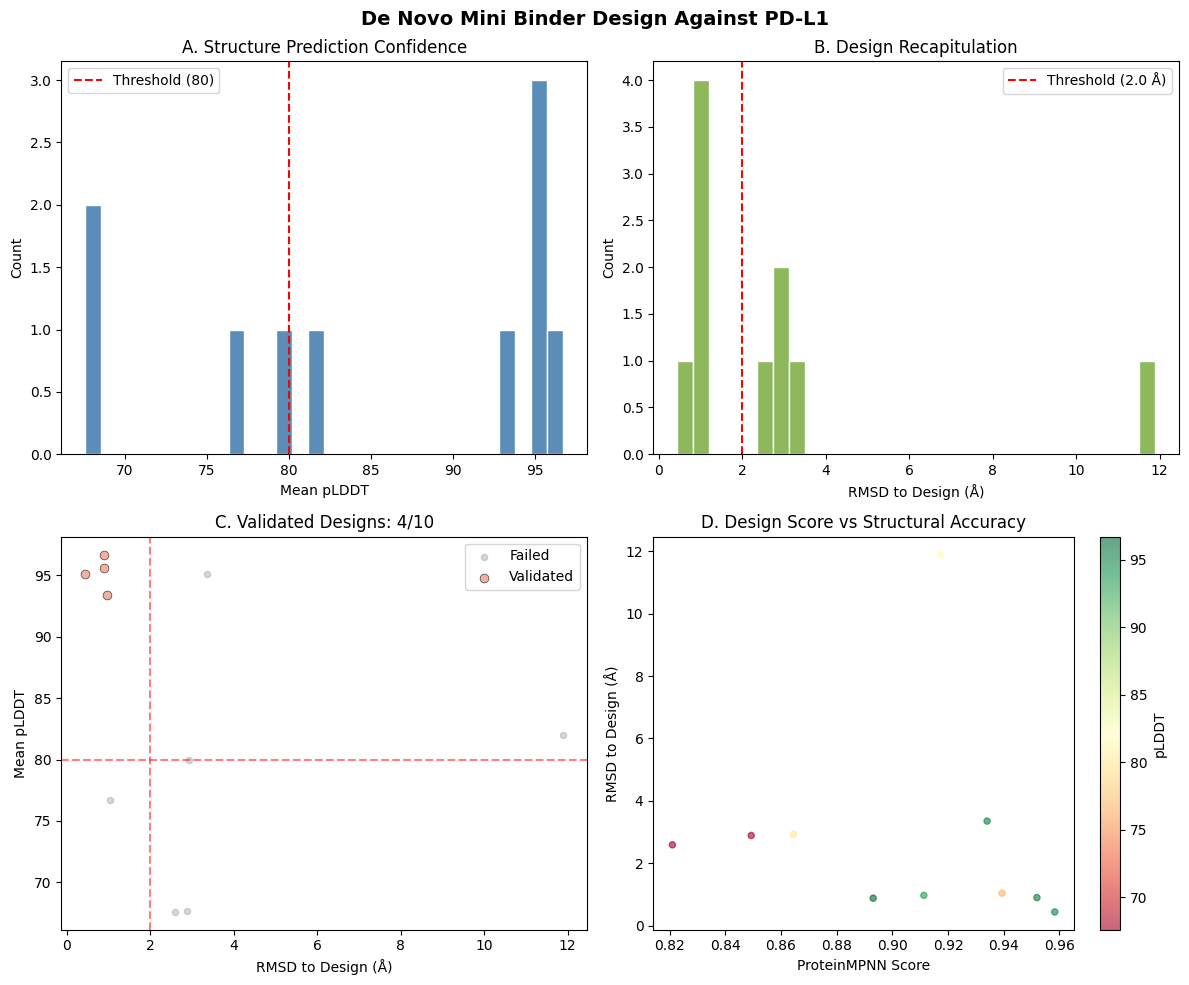


Final validated candidates: 4


In [10]:
# ============================================================
# Cell 2: Summary figure — the portfolio centerpiece
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: pLDDT distribution
axes[0,0].hist(df_all['mean_plddt'], bins=30, color='#5B8DB8', edgecolor='white')
axes[0,0].axvline(x=80, color='red', linestyle='--', label='Threshold (80)')
axes[0,0].set_xlabel('Mean pLDDT')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('A. Structure Prediction Confidence')
axes[0,0].legend()

# Panel B: RMSD distribution
axes[0,1].hist(df_all['rmsd'], bins=30, color='#8DB85B', edgecolor='white')
axes[0,1].axvline(x=2.0, color='red', linestyle='--', label='Threshold (2.0 Å)')
axes[0,1].set_xlabel('RMSD to Design (Å)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('B. Design Recapitulation')
axes[0,1].legend()

# Panel C: pLDDT vs RMSD — the key plot
validated = df_all[(df_all['mean_plddt'] > 80) & (df_all['rmsd'] < 2.0)]
not_validated = df_all[~((df_all['mean_plddt'] > 80) & (df_all['rmsd'] < 2.0))]

axes[1,0].scatter(not_validated['rmsd'], not_validated['mean_plddt'],
                  alpha=0.3, c='gray', s=20, label='Failed')
axes[1,0].scatter(validated['rmsd'], validated['mean_plddt'],
                  alpha=0.7, c='#E8927C', s=40, label='Validated', edgecolors='black', linewidth=0.5)
axes[1,0].axhline(y=80, color='red', linestyle='--', alpha=0.5)
axes[1,0].axvline(x=2.0, color='red', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('RMSD to Design (Å)')
axes[1,0].set_ylabel('Mean pLDDT')
axes[1,0].set_title(f'C. Validated Designs: {len(validated)}/{len(df_all)}')
axes[1,0].legend()

# Panel D: ProteinMPNN score vs validation success
axes[1,1].scatter(df_all['mpnn_score'], df_all['rmsd'],
                  c=df_all['mean_plddt'], cmap='RdYlGn', s=20, alpha=0.6)
axes[1,1].set_xlabel('ProteinMPNN Score')
axes[1,1].set_ylabel('RMSD to Design (Å)')
axes[1,1].set_title('D. Design Score vs Structural Accuracy')
cbar = plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])
cbar.set_label('pLDDT')

plt.suptitle('De Novo Mini Binder Design Against PD-L1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/harshadghodke/AIML/pdl1-mini-binder-design/figures/pipeline_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFinal validated candidates: {len(validated)}")

In [ ]:
# ============================================================
# Cell 3: Ranked candidate table
# ============================================================
# Final ranking: sort by RMSD (lower = better structural recapitulation)
# with pLDDT as tiebreaker

if len(validated) > 0:
    ranked = validated.sort_values(['rmsd', 'mean_plddt'], ascending=[True, False])
    ranked = ranked.reset_index(drop=True)
    ranked.index += 1  # 1-indexed ranking
    ranked.index.name = 'Rank'

    # Display top candidates
    display_cols = ['seq_id', 'backbone', 'mean_plddt', 'rmsd', 'mpnn_score', 'sequence']
    print("TOP VALIDATED MINI BINDER CANDIDATES")
    print("=" * 80)
    print(ranked[display_cols].head(20).to_string())

    # Save
    ranked.to_csv('data/results/final_ranked_candidates.csv')
    print(f"\nSaved {len(ranked)} ranked candidates")
else:
    print("No validated designs — see Troubleshooting section")